# Official HEC-HMS Guide Mirror: Meteorologic Methods

Official guides:

- https://www.hec.usace.army.mil/confluence/hmsdocs/hmsguides/meteorologic-methods-in-hms
- https://www.hec.usace.army.mil/confluence/hmsdocs/hmsguides/gridded-boundary-condition-data

This notebook maps the official meteorologic-method topics to hms-commander workflows: historical gage precipitation, gridded met inventories, frequency storm depth-duration curves, Atlas 14 temporal distributions, and SCS storm comparisons.

In [1]:
from pathlib import Path
import logging

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

logging.disable(logging.CRITICAL)


def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "hms_commander").is_dir() and (candidate / "examples").is_dir():
            return candidate
    return start


REPO_ROOT = find_repo_root()
WORK_ROOT = REPO_ROOT / "examples" / "working" / "clb238_guides"
WORK_ROOT.mkdir(parents=True, exist_ok=True)
HMS_VERSION = "4.13"

from hms_commander import HmsExamples, HmsPrj

available_versions = HmsExamples.list_versions()
if HMS_VERSION not in available_versions:
    HMS_VERSION = available_versions[0]
HMS_EXE = HmsExamples.get_hms_exe(HMS_VERSION)


def init_sample_project(project_name, notebook_key, overwrite=True):
    project_path = HmsExamples.extract_project(
        project_name,
        version=HMS_VERSION,
        output_path=WORK_ROOT / notebook_key,
        overwrite=overwrite,
    )
    project = HmsPrj()
    project.initialize(project_path, hms_exe_path=HMS_EXE)
    return project, project_path

In [2]:
from hms_commander import Atlas14Storm, FrequencyStorm, HmsDss, HmsGage, ScsTypeStorm

castro, castro_path = init_sample_project("castro", "102_meteorologic_methods/castro")
tenk, tenk_path = init_sample_project("tenk", "102_meteorologic_methods/tenk")

met_inventory = pd.concat([
    castro.met_df.assign(sample_project="castro"),
    tenk.met_df.assign(sample_project="tenk"),
], ignore_index=True)
met_view = met_inventory[[
    "sample_project", "name", "precip_method", "et_method",
    "snowmelt_method", "num_subbasin_assignments",
]]

gage_file = next(castro_path.glob("*.gage"))
gage_summary = HmsGage.get_gages(gage_file)[["name", "type", "units", "dss_file", "dss_pathname"]]
gage_summary["dss_file"] = gage_summary["dss_file"].map(lambda value: Path(value).name if value else "")

display(met_view)
display(gage_summary)

,sample_project,name,precip_method,et_method,snowmelt_method,num_subbasin_assignments
0,castro,GageWts,Weighted Gages,No Evapotranspiration,None,4
1,tenk,Stage3-HRAP,Gridded Precipitation,No Evapotranspiration,None,4


,name,type,units,dss_file,dss_pathname
0,Fire Dept.,Precipitation,,,
1,Out,Precipitation,,,


Configuring Java VM for DSS operations...
[OK] Java VM configured


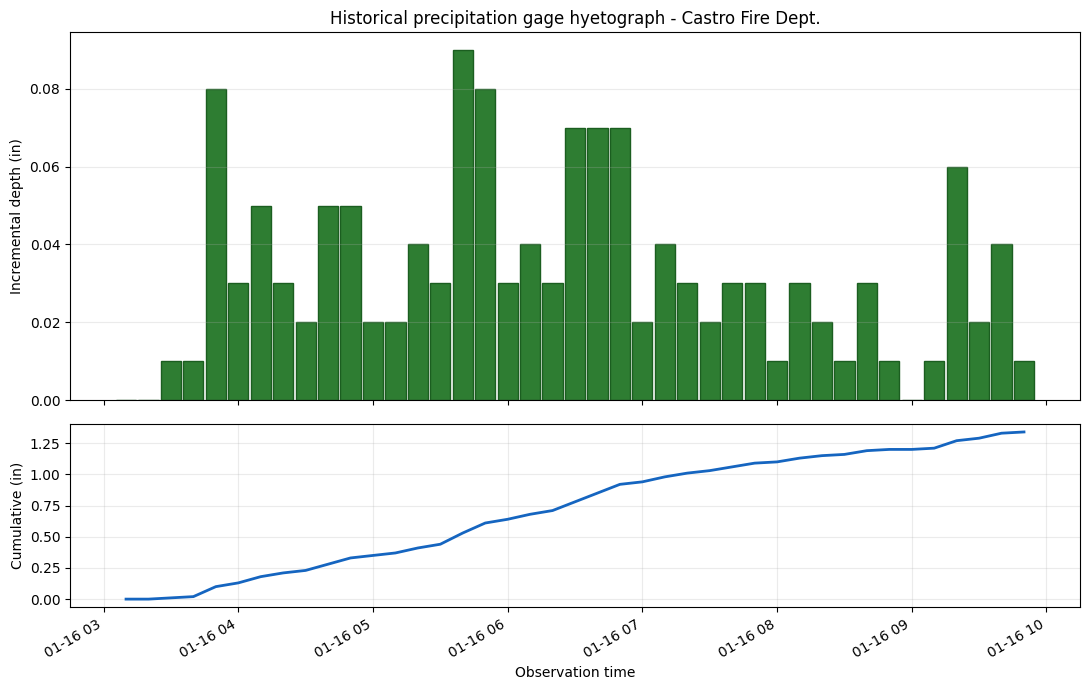

,gage_pathname,interval_minutes,total_depth_in,peak_increment_in,time_steps
0,/CASTRO VALLEY/FIRE DEPT./PRECIP-INC//10MIN/OBS/,10,1.34,0.09,41


In [3]:
observed_refs = castro.get_observed_dss_paths()
precip_dss, precip_path = next(
    (dss_path, pathname) for dss_path, pathname in observed_refs
    if "PRECIP" in pathname.upper()
)
gage_precip = HmsDss.read_timeseries(precip_dss, precip_path)
interval_minutes = int(gage_precip.attrs.get("interval", 10))
bar_width_days = interval_minutes / (60 * 24) * 0.9

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True, height_ratios=[2, 1])
ax1.bar(gage_precip.index, gage_precip["value"], width=bar_width_days, color="#2e7d32", edgecolor="#1b5e20")
ax1.set_title("Historical precipitation gage hyetograph - Castro Fire Dept.")
ax1.set_ylabel("Incremental depth (in)")
ax1.grid(True, axis="y", alpha=0.25)

cumulative = gage_precip["value"].cumsum()
ax2.plot(gage_precip.index, cumulative, color="#1565c0", linewidth=2)
ax2.set_ylabel("Cumulative (in)")
ax2.set_xlabel("Observation time")
ax2.grid(True, alpha=0.25)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

pd.DataFrame([{
    "gage_pathname": precip_path,
    "interval_minutes": interval_minutes,
    "total_depth_in": round(float(gage_precip["value"].sum()), 3),
    "peak_increment_in": round(float(gage_precip["value"].max()), 3),
    "time_steps": len(gage_precip),
}])

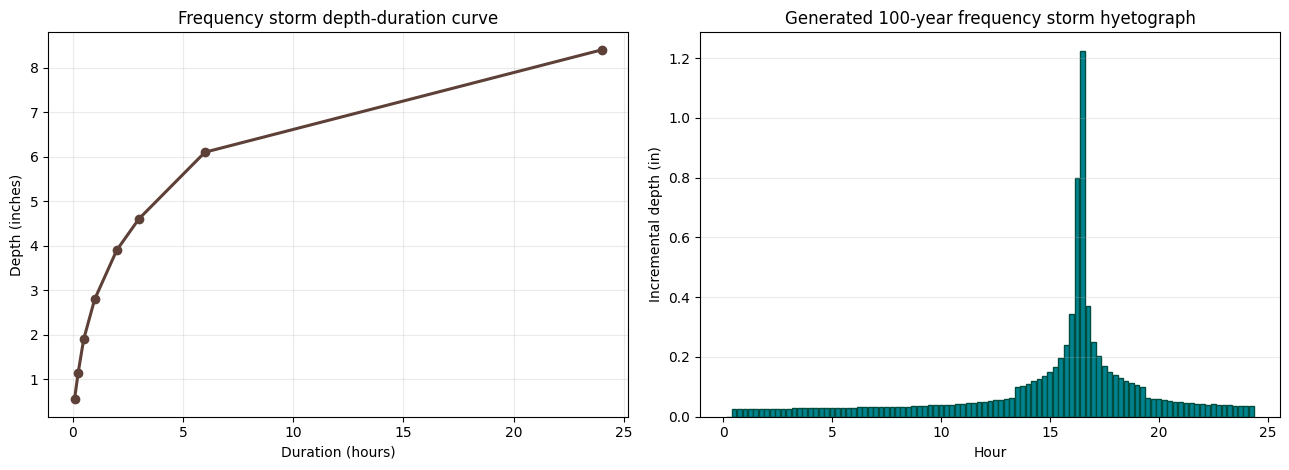

,name,precip_method,num_subbasin_assignments
0,Stage3-HRAP,Gridded Precipitation,4


,asset_type,file,exists,size_bytes
0,grid_definition,tenk.grid,True,412


In [4]:
gridded_met = tenk.met_df.loc[tenk.met_df["precip_method"].str.contains("Gridded", case=False, na=False)]
gridded_assets = pd.DataFrame([
    {"asset_type": "grid_definition", "file": path.name, "exists": path.exists(), "size_bytes": path.stat().st_size}
    for path in sorted(tenk_path.glob("*.grid"))
])
assert not gridded_met.empty
assert not gridded_assets.empty

durations = np.array(Atlas14Storm.FREQUENCY_STORM_DURATIONS_MIN, dtype=int)
example_depth_table = pd.DataFrame({
    "duration_minutes": durations,
    100: [0.55, 1.15, 1.90, 2.80, 3.90, 4.60, 6.10, 8.40],
})
frequency_depths = Atlas14Storm.build_frequency_storm_depths(example_depth_table, ari_years=100)
frequency_hyetograph = FrequencyStorm.generate_from_ddf(
    frequency_depths,
    durations=durations,
    peak_position_pct=67.0,
    time_interval_min=15,
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8))
ax1.plot(durations / 60, frequency_depths, marker="o", linewidth=2.2, color="#5d4037")
ax1.set_title("Frequency storm depth-duration curve")
ax1.set_xlabel("Duration (hours)")
ax1.set_ylabel("Depth (inches)")
ax1.grid(True, alpha=0.25)

ax2.bar(
    frequency_hyetograph["hour"],
    frequency_hyetograph["incremental_depth"],
    width=0.22,
    color="#00838f",
    edgecolor="#004d40",
)
ax2.set_title("Generated 100-year frequency storm hyetograph")
ax2.set_xlabel("Hour")
ax2.set_ylabel("Incremental depth (in)")
ax2.grid(True, axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

display(gridded_met[["name", "precip_method", "num_subbasin_assignments"]])
display(gridded_assets)

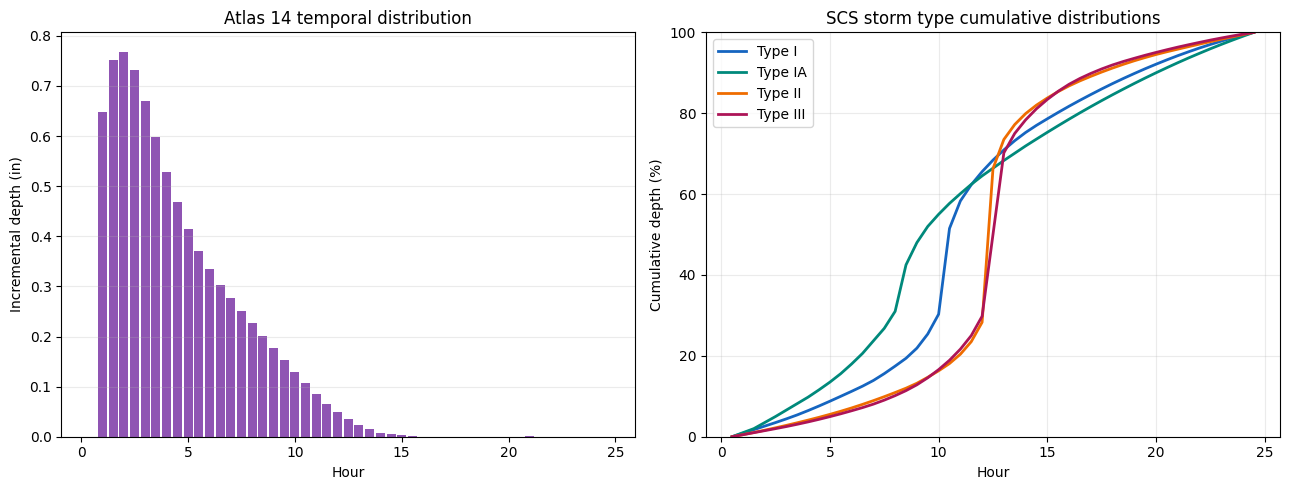

,storm,rows,total_depth_in,peak_increment_in
0,Atlas 14 All Cases,49,8.4,0.769
1,SCS Type I,49,8.4,1.781
2,SCS Type IA,49,8.4,0.966
3,SCS Type II,49,8.4,3.192
4,SCS Type III,49,8.4,1.697


In [5]:
atlas14_hyetograph = Atlas14Storm.generate_hyetograph(
    total_depth_inches=8.40,
    state="tx",
    region=3,
    duration_hours=24,
    aep_percent=1.0,
    quartile="All Cases",
    probability_column="50%",
)
scs_hyetographs = {
    scs_type: ScsTypeStorm.generate_hyetograph(8.40, scs_type=scs_type, time_interval_min=30)
    for scs_type in ScsTypeStorm.SCS_TYPES
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ax1.bar(
    atlas14_hyetograph["hour"],
    atlas14_hyetograph["incremental_depth"],
    width=0.42,
    color="#6a1b9a",
    alpha=0.75,
)
ax1.set_title("Atlas 14 temporal distribution")
ax1.set_xlabel("Hour")
ax1.set_ylabel("Incremental depth (in)")
ax1.grid(True, axis="y", alpha=0.25)

colors = {"I": "#1565c0", "IA": "#00897b", "II": "#ef6c00", "III": "#ad1457"}
for scs_type, hyeto in scs_hyetographs.items():
    ax2.plot(
        hyeto["hour"],
        hyeto["cumulative_depth"] / hyeto["cumulative_depth"].iloc[-1] * 100,
        linewidth=2,
        color=colors[scs_type],
        label=f"Type {scs_type}",
    )
ax2.set_title("SCS storm type cumulative distributions")
ax2.set_xlabel("Hour")
ax2.set_ylabel("Cumulative depth (%)")
ax2.set_ylim(0, 100)
ax2.grid(True, alpha=0.25)
ax2.legend()
plt.tight_layout()
plt.show()

storm_checks = pd.DataFrame([
    {
        "storm": "Atlas 14 All Cases",
        "rows": len(atlas14_hyetograph),
        "total_depth_in": round(float(atlas14_hyetograph["cumulative_depth"].iloc[-1]), 3),
        "peak_increment_in": round(float(atlas14_hyetograph["incremental_depth"].max()), 3),
    },
    *[
        {
            "storm": f"SCS Type {scs_type}",
            "rows": len(hyeto),
            "total_depth_in": round(float(hyeto["cumulative_depth"].iloc[-1]), 3),
            "peak_increment_in": round(float(hyeto["incremental_depth"].max()), 3),
        }
        for scs_type, hyeto in scs_hyetographs.items()
    ],
])
storm_checks

## Coverage Notes

This notebook covers historical gage precipitation, gridded precipitation project assets, frequency storms, Atlas 14 temporal patterns, and SCS temporal distributions. Higher-level authoring for every HMS meteorologic method remains an API expansion area tracked outside this notebook series.